# BA820: Milestone IV - Refinement
**Course:** BA820 - Unsupervised and Unstructured Machine Learning

**Author:** Riya Poojary

**Dataset:** Hollywood Age Gaps (age_gaps.csv)



## I. Dataset Overview: Hollywood Age Gaps

**In Milestone 3, the team integrated the work:**
- Using a shared preprocessing approach across members.

- Comparing individual and combined feature sets.

- Checking whether clustering patterns stayed similar across methods and feature sets.

- Evaluating whether combined features improved interpretation or added redundancy.


**In Milestone 4, I will refine and strengthen our findings by:**

- Using a simpler baseline clustering setup for clearer interpretation (`age_difference`, k=2)

- Comparing KMeans with hierarchical clustering on the same main sample.

- Using ARI to measure agreement between clustering methods.

- Examining cluster proportions across decades as a descriptive time-based check.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Load dataset
df = pd.read_csv("age_gaps.csv")
df.head()

,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38


## II. Data Preparation and Preprocessing Updates
Before clustering, let's check how pairing types are distributed in the cleaned dataset to identify imbalance across categories. This is important because strong imbalance can affect both the clustering results and the interpretation of findings.

In [13]:
df_clean = df.copy()

print("Original shape:", df_clean.shape)

# Clean gender columns
df_clean["character_1_gender"] = df_clean["character_1_gender"].astype(str).str.lower().str.strip()
df_clean["character_2_gender"] = df_clean["character_2_gender"].astype(str).str.lower().str.strip()

gender_map = {"male": "man", "female": "woman", "m": "man", "f": "woman"}
df_clean["character_1_gender"] = df_clean["character_1_gender"].replace(gender_map)
df_clean["character_2_gender"] = df_clean["character_2_gender"].replace(gender_map)

# Numeric columns are numeric
df_clean["release_year"] = pd.to_numeric(df_clean["release_year"], errors="coerce")
df_clean["actor_1_age"] = pd.to_numeric(df_clean["actor_1_age"], errors="coerce")
df_clean["actor_2_age"] = pd.to_numeric(df_clean["actor_2_age"], errors="coerce")

# Create age_difference
df_clean["age_difference"] = (df_clean["actor_1_age"] - df_clean["actor_2_age"]).abs()

# Create age_main
df_clean["age_main"] = (df_clean["actor_1_age"] + df_clean["actor_2_age"]) / 2

# Create pairing_type
df_clean["pairing_type"] = df_clean["character_1_gender"] + "-" + df_clean["character_2_gender"]

# Create decade variable
df_clean["decade"] = (df_clean["release_year"] // 10) * 10

# Drop rows missing important values
df_clean = df_clean.dropna(subset=["actor_1_age", "actor_2_age", "release_year", "age_difference", "pairing_type", "decade"]).copy()
df_clean["decade"] = df_clean["decade"].astype(int)

print("\nFinal shape after preprocessing:", df_clean.shape)

print("\nPreview of new features:")
display(df_clean[["age_difference", "age_main", "pairing_type", "decade"]].head())


Original shape: (1155, 13)

Final shape after preprocessing: (1155, 16)

Preview of new features:


,age_difference,age_main,pairing_type,decade
0,52,49.0,woman-man,1970
1,50,49.0,man-woman,2000
2,49,44.5,man-woman,2000
3,45,45.5,man-woman,1990
4,43,59.5,man-man,2010


In [14]:
MAIN_PAIRINGS = ["man-woman", "woman-man"]
age_main = df_clean[df_clean["pairing_type"].isin(MAIN_PAIRINGS)].copy()

print(f"Main sample rows: {len(age_main)}")
print(f"Main pairings share of cleaned data: {round(len(age_main)/len(df_clean)*100,1)}% ({len(age_main)}/{len(df_clean)})")
display(age_main["pairing_type"].value_counts())


Main sample rows: 1132
Main pairings share of cleaned data: 98.0% (1132/1155)


,count
pairing_type,
man-woman,929
woman-man,203


- The results show that opposite-gender pairings account for 98.0% of the cleaned dataset (1132 out of 1155 records), while same-gender pairings represent only a small share.

- This indicates a strong imbalance in pairing type, so later clustering results are less likely to be driven by pairing composition alone.

- Therefore, differences in age-related features are more likely to explain the cluster structure and interpretation.

## III. KMeans Results: Sensitivity Checks and Baseline



### III.1 Sensitivity Check (k=2 vs k=3 on Scaled Features)

- To check whether the clustering pattern is stable, I compare KMeans with `k=2` and `k=3` using a scaled version of `age_difference` and `decade` on the main sample (`man-woman` and `woman-man`).
- I use the silhouette score as a simple way to compare cluster separation, where a higher value means the groups are more clearly separated in this setup.


In [15]:
main_df = df_clean[df_clean["pairing_type"].isin(["man-woman", "woman-man"])].copy()
main_df = main_df.dropna(subset=["age_difference", "decade"]).copy()
print("Main sample size:", main_df.shape[0])

# Select features
features = ["age_difference", "decade"]
X = main_df[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans with k = 2 (M2 choice)
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_2 = kmeans_2.fit_predict(X_scaled)
sil_2 = silhouette_score(X_scaled, labels_2)

print("\nKMeans (k=2) Silhouette Score:", round(sil_2, 3))
print("Cluster sizes (k=2):")
print(pd.Series(labels_2).value_counts().sort_index())

# KMeans with k = 3 (M3 choice)
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(X_scaled)
sil_3 = silhouette_score(X_scaled, labels_3)

print("\nKMeans (k=3) Silhouette Score:", round(sil_3, 3))
print("Cluster sizes (k=3):")
print(pd.Series(labels_3).value_counts().sort_index())

Main sample size: 1132

KMeans (k=2) Silhouette Score: 0.501
Cluster sizes (k=2):
0    870
1    262
Name: count, dtype: int64

KMeans (k=3) Silhouette Score: 0.487
Cluster sizes (k=3):
0    271
1    738
2    123
Name: count, dtype: int64


- The main sample includes **1,132 observations** after limiting the data to `man-woman` and `woman-man` pairings.
- In this sensitivity check, the **k=2 model gives a slightly higher silhouette score (0.501)** than the **k=3 model (0.487)**.
- This means the **2-cluster solution separates the data a little more clearly** for this scaled feature set (`age_difference`, `decade`).


### III.2 Baseline KMeans (k=2 on Age Difference Only)

- I now return to the simpler baseline KMeans setup (`k=2` using `age_difference` only) for the main cluster interpretation.
- This baseline is easier to interpret because it directly captures age-gap differences without adding `decade`.


In [16]:
main_df = df_clean[df_clean["pairing_type"].isin(["man-woman", "woman-man"])].copy()
main_df = main_df.dropna(subset=["age_difference"]).copy()

X_age = main_df[["age_difference"]]

print("Main sample size:", main_df.shape[0])

# KMeans with k = 2
kmeans_age = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_age = kmeans_age.fit_predict(X_age)
sil_age = silhouette_score(X_age, labels_age)

print("\nBaseline (age_difference only, k=2) Silhouette Score:", round(sil_age, 3))
print("Cluster centers (age_difference):", kmeans_age.cluster_centers_.flatten())
print("Cluster sizes:")
print(pd.Series(labels_age).value_counts())

Main sample size: 1132

Baseline (age_difference only, k=2) Silhouette Score: 0.645
Cluster centers (age_difference): [ 6.16466346 22.01666667]
Cluster sizes:
0    832
1    300
Name: count, dtype: int64


- The baseline KMeans model uses 1,132 observations from the main sample (man-woman and woman-man pairings) and clusters them into two groups using age_difference only.

- The two cluster centers are approximately 6.16 years and 22.02 years, which supports interpreting the clusters as a small-gap group and a large-gap group.

- The silhouette score is 0.645, which suggests the 2-cluster split is reasonably well separated for this one-variable baseline setup.

- In terms of size, the clusters contain 832 and 300 observations (about 73.5% and 26.5% of the main sample, respectively), indicating that most observations fall into the smaller age-gap group.

## IV. Hierarchical Clustering Validation

- Hierarchical (agglomerative) clustering is run on the **same main sample** and the same baseline feature (**age_difference** only).
- The goal is to check whether the main clustering pattern is consistent across methods (not driven only by KMeans).
- Similarity between KMeans and hierarchical labels is measured using **Adjusted Rand Index (ARI)**:
  - **ARI = 1** - perfect match  
  - **ARI ≈ 0** - random-like agreement  
  - **ARI < 0** - worse than random agreement

Before running hierarchical clustering with **k = 2**, the dendrogram for **age_difference** is checked to make sure the data supports a two-group split. The merge pattern shows a clear separation between movies with **smaller age gaps** and movies with **larger age gaps**, which matches the intuition behind using two clusters.

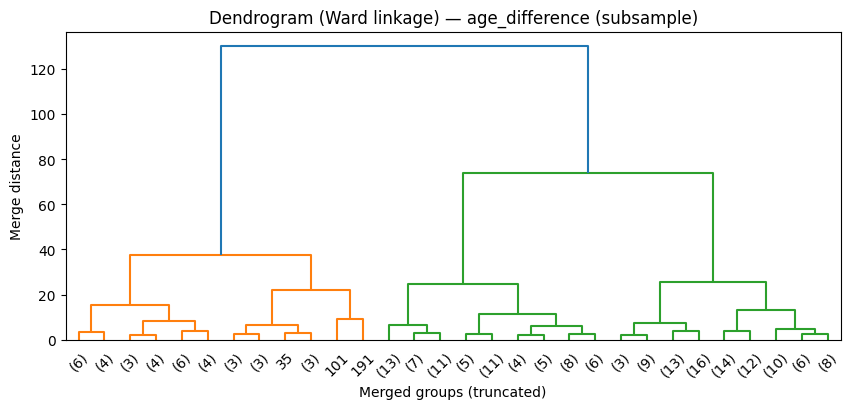

In [17]:
X = main_df[["age_difference"]].dropna()
sample_size = min(200, len(X))
X_plot = X.sample(n=sample_size, random_state=42)
Z = linkage(X_plot.values, method="ward")

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode="lastp", show_leaf_counts=True)
plt.title("Dendrogram (Ward linkage) — age_difference (subsample)")
plt.xlabel("Merged groups (truncated)")
plt.ylabel("Merge distance")
plt.show()

- The dendrogram splits into **two big branches**, which lines up with **two groups in age_difference**.
- There is a **clear jump in merge distance** near the top, meaning these two branches are quite different and should not be forced together.
- This supports using **k = 2** (one smaller-gap cluster and one larger-gap cluster).

In [18]:
main_df = df_clean[df_clean["pairing_type"].isin(["man-woman", "woman-man"])].copy()
main_df = main_df.dropna(subset=["age_difference"]).copy()
X_age = main_df[["age_difference"]]

print("Main sample size:", main_df.shape[0])

# Hierarchical clustering
hier = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels_hier = hier.fit_predict(X_age)

# Silhouette score
sil_hier = silhouette_score(X_age, labels_hier)

print("\nHierarchical (k=2) Silhouette Score:", round(sil_hier, 3))
print("Cluster sizes:")
print(pd.Series(labels_hier).value_counts())

# Summary
main_df["hier_cluster"] = labels_hier
print("\nAge gap summary by hierarchical cluster:")
print(main_df.groupby("hier_cluster")["age_difference"].describe().round(2))

Main sample size: 1132

Hierarchical (k=2) Silhouette Score: 0.643
Cluster sizes:
1    802
0    330
Name: count, dtype: int64

Age gap summary by hierarchical cluster:
              count   mean   std   min   25%   50%   75%   max
hier_cluster                                                  
0             330.0  21.29  6.54  14.0  16.0  20.0  25.0  52.0
1             802.0   5.87  3.73   0.0   3.0   5.0   9.0  13.0


In [19]:
# Refit KMeans
kmeans_compare = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans = kmeans_compare.fit_predict(X_age)

# ARI comparison
ari = adjusted_rand_score(labels_kmeans, labels_hier)
print("Adjusted Rand Index (KMeans vs Hierarchical):", round(ari, 3))

Adjusted Rand Index (KMeans vs Hierarchical): 0.893


- **Silhouette (Hierarchical, k=2)** = **0.643**, very close to the KMeans baseline (**0.645**).
- The same two-group pattern appears:
  - **Smaller age-gap cluster:** mean ≈ **5.87** years (n = **802**)
  - **Larger age-gap cluster:** mean ≈ **21.29** years (n = **330**)
- **ARI (KMeans vs Hierarchical)** = **0.893**, showing strong agreement across methods.
- Overall, the clustering pattern is consistent across KMeans and hierarchical clustering, suggesting the result is **stable**.

## V. Cluster Composition by Decade (Descriptive Check)
- In this section, I examine how the baseline KMeans clusters (k=2, using `age_difference` only) are distributed across decades.
- This is a descriptive check to see whether the share of the small-gap vs large-gap cluster changes over time.
- I report cluster percentages **within each decade** (so the percentages in each row add up to 100%).

Percentage of Each Cluster by Decade (within decade):
gap_group  large_gap  small_gap
decade                         
1930            28.6       71.4
1940            75.0       25.0
1950            64.7       35.3
1960            17.1       82.9
1970            50.0       50.0
1980            46.0       54.0
1990            27.1       72.9
2000            19.2       80.8
2010            24.2       75.8
2020            41.2       58.8
decade
1930      7
1940     12
1950     34
1960     35
1970     30
1980     50
1990    221
2000    400
2010    326
2020     17
Name: count, dtype: int64


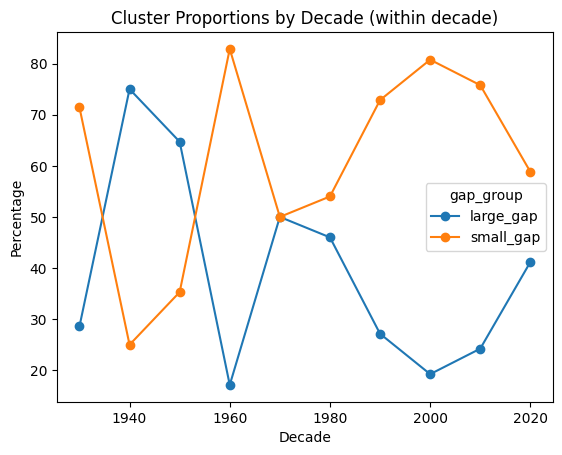

In [20]:
main_df = df_clean[df_clean["pairing_type"].isin(["man-woman", "woman-man"])].copy()
main_df = main_df.dropna(subset=["age_difference", "decade"]).copy()

X_age = main_df[["age_difference"]]
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
main_df["cluster"] = kmeans.fit_predict(X_age)

# Cluster is large-gap
cluster_means = main_df.groupby("cluster")["age_difference"].mean()
large_cluster = cluster_means.idxmax()
main_df["gap_group"] = main_df["cluster"].apply(lambda x: "large_gap" if x == large_cluster else "small_gap")

# Percentage distribution by decade
cluster_decade = (main_df.groupby("decade")["gap_group"].value_counts(normalize=True).unstack()) * 100

print("Percentage of Each Cluster by Decade (within decade):")
print(cluster_decade.round(1))
print(main_df["decade"].value_counts().sort_index())

# Plot
cluster_decade.plot(marker="o")
plt.title("Cluster Proportions by Decade (within decade)")
plt.ylabel("Percentage")
plt.xlabel("Decade")
plt.show()

- The table and plot show the percentage of films in the small-gap and large-gap clusters **within each decade** (each decade sums to 100%).
- In the larger-sample recent decades, the small-gap cluster is more common, while the large-gap cluster remains a smaller share.
- Some early decades show sharp swings, but those decades have very small counts, so these percentages are less stable.
- Overall, the two-cluster age-gap pattern remains meaningful across decades but the **balance between small-gap and large-gap films changes over time**.

## VI. Refined Insights

Milestone 4 refines and strengthens the integrated results from Milestone 3. Using the main sample (man-woman and woman-man pairings), the analysis continues to show a clear and interpretable two-cluster structure: a **smaller age-gap** cluster and a **larger age-gap** cluster.

This pattern is supported by both **KMeans** and **Hierarchical Clustering**, and the **high Adjusted Rand Index (ARI)** suggests strong agreement between the two methods. The decade-level analysis also shows that the proportions of these clusters change across decades, while the overall age-gap-based clustering pattern remains stable and useful for interpretation.

Overall, M4 improves the analysis by making the results easier to interpret, clearly defining the evaluation metrics and showing that the main findings are not dependent on a single clustering method.